Data Shape: (442, 10) (442,)
Min: 25.0
Max: 346.0
Mean: 152.13348416289594
Standar Deviation: 77.00574586945044
Mean Squared Error:3272.5322
Predicted value:[162.69217 185.40611 112.5117 ]


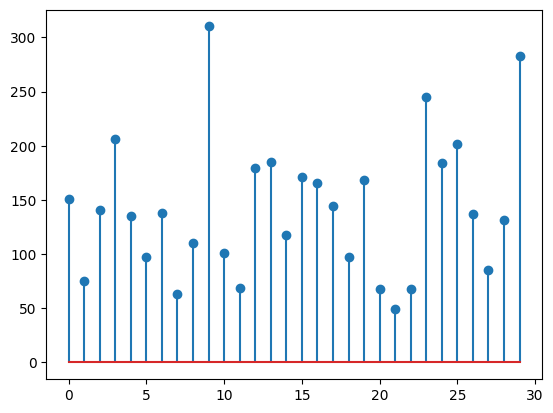

In [7]:
import xgboost as xgb
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split 

diabetes = load_diabetes()
x,y = diabetes.data,diabetes.target

print("Data Shape:",x.shape,y.shape)
from matplotlib import pyplot as plt 
%matplotlib inline
 
plt.stem(range(30),y[:30])
import numpy as np

print("Min:",np.min(y))
print("Max:",np.max(y))
print("Mean:",np.mean(y))
print("Standar Deviation:",np.std(y))
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

dtrain = xgb.DMatrix(x_train,label=y_train)
dtest = xgb.DMatrix(x_test,label=y_test)

params = {
    'objective':'reg:squarederror',
#     常见取值：（支持自定义函数）
# 回归：reg:squarederror（均方误差，最常用）、reg:absoluteerror（平均绝对误差）
# 分类：binary:logistic（二分类，输出概率）、multi:softmax（多分类，输出类别）
    'max_depth':4,
    'eta':0.1,
    'subsample':0.8,
    'colsample_bytree':0.8
}

model = xgb.train(params,dtrain,num_boost_round=100)

from sklearn.metrics import mean_squared_error

y_pred = model.predict(dtest)

mse = mean_squared_error(y_test,y_pred)
print(f"Mean Squared Error:{mse:.4f}")
new_data = np.random.randn(3,10)
dnew = xgb.DMatrix(new_data)
new_pred = model.predict(dnew)
print(f"Predicted value:{new_pred}")
plt.show()


In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

x,y = iris.data,iris.target
print(x.shape,y.shape)
print(set(y))
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


import xgboost as xgb 
dtrain = xgb.DMatrix(x_train,label = y_train)
dtest = xgb.DMatrix(x_test,label=y_test)

params = {
    'objective':'multi:softmax',
    'num_class':3,
    'max_depth':4,
    'eta':0.1,
    'subsample':0.8,
    'colsample_bytree':0.8
}

model = xgb.train(params,dtrain,num_boost_round=100)


(150, 4) (150,)
{0, 1, 2}


Accuracy:1.0000
(30, 4)
(30,)
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


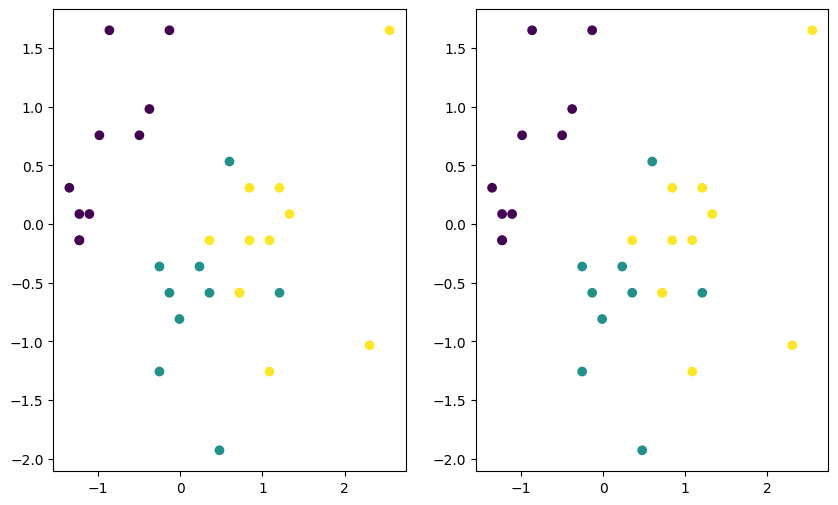

Predicted class: [2. 0. 0.]


In [3]:

from sklearn.metrics import accuracy_score

y_pred = model.predict(dtest)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.4f}")
from matplotlib import pyplot as plt 
%matplotlib inline

print(x_test.shape)
print(y_test.shape)
print(y_test)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,6))
ax1.scatter(x_test[:,0],x_test[:,1],c=y_test)
ax2.scatter(x_test[:,0],x_test[:,1],c=y_pred)
plt.show()
import numpy as np
new_data = np.random.randn(3, 4)
dnew = xgb.DMatrix(new_data)
new_pred = model.predict(dnew)
print(f"Predicted class: {new_pred}")

In [6]:
import numpy as np 
from sklearn.model_selection import train_test_split
import xgboost as xgb 
from sklearn.metrics import ndcg_score  
# NDCG（Normalized Discounted Cumulative Gain，归一化折损累计增益

from matplotlib import pyplot as plt 
%matplotlib inline 

n_queries = 5
n_docs_per_query = 10
n_features = 2

x = np.random.rand(n_queries * n_docs_per_query, n_features)

y = np.hstack([np.random.permutation(n_docs_per_query) for _ in range(n_queries)])
 
query_ids = np.repeat(np.arange(n_queries),n_docs_per_query)

print(x.shape,y.shape,query_ids.shape)
print(x[:10,:])
print(y)
print(query_ids)
x_train,x_test,y_train,y_test,query_train, \
    query_test = train_test_split(x,y,query_ids,test_size=0.2,random_state=42)


dtrain = xgb.DMatrix(x_train,label=y_train)
dtest = xgb.DMatrix(x_test,label=y_test)

params = {
    'objective':'rank:pairwise',
    'max_depth':4,
    'eta':0.1,
    'subsample':0.8,
    'colsample_bytree':0.8
}

model = xgb.train(params,dtrain,num_boost_round=100)


(50, 2) (50,) (50,)
[[0.52892625 0.42640995]
 [0.59007031 0.30398069]
 [0.13423064 0.17976999]
 [0.63137053 0.33365078]
 [0.09312528 0.02626488]
 [0.87011659 0.02968751]
 [0.8388337  0.10975656]
 [0.77079551 0.52585804]
 [0.41329778 0.86002034]
 [0.34321532 0.72191585]]
[9 6 5 3 7 1 4 0 2 8 7 4 6 3 5 2 8 0 1 9 0 2 7 6 5 8 1 3 4 9 9 2 8 0 6 7 5
 1 3 4 5 9 3 1 2 0 7 4 6 8]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3
 3 3 3 4 4 4 4 4 4 4 4 4 4]


In [8]:

from sklearn.metrics import ndcg_score  
y_pred = model.predict(dtest)
print(x_test)
print('y_pred',y_pred)
print('y_test',y_test)
print('query test:',query_test)

ndcg_scores = []

for i in np.unique(query_test):
    idx = np.where(query_test==i)

    y_true_query = np.array([y_test[idx]])
    y_pred_query = np.array([y_pred[idx]])
    print(f"第{i}个查询")
    print('y_true_query:',y_true_query)
    print('y_pred_query',y_pred_query)
    ndcg = ndcg_score(y_true_query, y_pred_query)
    ndcg_scores.append(ndcg)

# 输出平均 NDCG 得分
avg_ndcg = np.mean(ndcg_scores)
print(f"Average NDCG Score: {avg_ndcg}")


[[0.72816271 0.18721165]
 [0.13759966 0.13102388]
 [0.57264454 0.66944553]
 [0.39827733 0.10400629]
 [0.80276925 0.48740483]
 [0.9909239  0.21109989]
 [0.57327883 0.21183742]
 [0.43951831 0.7925209 ]
 [0.36903889 0.81576761]
 [0.59490043 0.74039035]]
y_pred [-0.22635622  0.3897514   0.04821767  0.1673927   0.07812952 -0.38511556
  0.15938622  0.20417348  0.41500154  0.7028205 ]
y_test [3 4 9 0 0 6 1 8 8 9]
query test: [1 3 3 4 1 4 2 2 3 1]
第1个查询
y_true_query: [[3 0 9]]
y_pred_query [[-0.22635622  0.07812952  0.7028205 ]]
第2个查询
y_true_query: [[1 8]]
y_pred_query [[0.15938622 0.20417348]]
第3个查询
y_true_query: [[4 9 8]]
y_pred_query [[0.3897514  0.04821767 0.41500154]]
第4个查询
y_true_query: [[0 6]]
y_pred_query [[ 0.1673927  -0.38511556]]
Average NDCG Score: 0.8827692219417239


In [9]:
new_data = np.random.rand(3, 2)
dnew = xgb.DMatrix(new_data)
new_pred = model.predict(dnew)
print(f"Predicted rank score: {new_pred}")

Predicted rank score: [-0.06794498 -0.04205555 -0.09335843]
